## 1. Data Loading and Initial Inspection

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from scipy.spatial.distance import cosine
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

In [2]:
# Load the dataset
df = pd.read_csv('/content/multilingual_code_comments_backup_v2.csv')
print("Dataset loaded successfully.")

# Display Basic Information
print("\nFirst 5 rows of the dataset:")
display(df.head())

print("\nDataset Info:")
df.info()

print("\nDataset Description (for numerical columns, if any):")
display(df.describe())

print("\nDataset Shape (rows, columns):")
print(df.shape)

# Check for Missing Values
print("\nMissing values per column:")
print(df.isnull().sum())

# Inspect Unique Values in Key Categorical Columns
print("\nUnique Programming Languages:")
print(df['programming_language'].unique())

print("\nUnique Target Language Codes:")
print(df['target_language_code'].unique())

print("\nUnique Comment Intents:")
print(df['comment_intent'].unique())

print("\nUnique Source URLs:")
print(df['source_url'].unique())

Dataset loaded successfully.

First 5 rows of the dataset:


,unique_id,code_snippet,programming_language,comment_english,target_language_code,comment_target_lang,comment_intent,source_url,comment_english_processed,comment_target_lang_processed,code_snippet_processed
0,XLCoST_1,"def hello_world():\n print('Hello, world!')",Python,"Prints Hello, world! to the console.",en,"Prints Hello, world! to the console.",Functionality,XLCoST_Dataset,prints hello world to the console,prints hello world to the console,def hello_world():\n print(<STR>)
1,XLCoST_2,public static void main(String[] args) {\n ...,Java,"Main method that prints Hello, world! in Java.",en,"Main method that prints Hello, world! in Java.",Functionality,XLCoST_Dataset,main method that prints hello world in java,main method that prints hello world in java,public static void main(String[] args) {\n ...
2,XLCoST_1_TRANSLATED_hi,"def hello_world():\n print('Hello, world!')",Python,"Prints Hello, world! to the console.",hi,"हैलो, दुनिया प्रिंट!कंसोल के लिए।",Translated,XLCoST_Dataset,prints hello world to the console,हल दनय परटकसल क लए,def hello_world():\n print(<STR>)
3,XLCoST_1_TRANSLATED_ta,"def hello_world():\n print('Hello, world!')",Python,"Prints Hello, world! to the console.",ta,"ஹலோ, உலகம்!கன்சோலுக்கு.",Translated,XLCoST_Dataset,prints hello world to the console,ஹல உலகமகனசலகக,def hello_world():\n print(<STR>)
4,XLCoST_1_TRANSLATED_te,"def hello_world():\n print('Hello, world!')",Python,"Prints Hello, world! to the console.",te,"ప్రింట్లు హలో, ప్రపంచం!కన్సోల్‌కు.",Translated,XLCoST_Dataset,prints hello world to the console,పరటల హల పరపచకనసలక,def hello_world():\n print(<STR>)



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   unique_id                      1500 non-null   object
 1   code_snippet                   1500 non-null   object
 2   programming_language           1500 non-null   object
 3   comment_english                1500 non-null   object
 4   target_language_code           1500 non-null   object
 5   comment_target_lang            1500 non-null   object
 6   comment_intent                 1500 non-null   object
 7   source_url                     1500 non-null   object
 8   comment_english_processed      1500 non-null   object
 9   comment_target_lang_processed  1500 non-null   object
 10  code_snippet_processed         1500 non-null   object
dtypes: object(11)
memory usage: 129.0+ KB

Dataset Description (for numerical columns, if any):


,unique_id,code_snippet,programming_language,comment_english,target_language_code,comment_target_lang,comment_intent,source_url,comment_english_processed,comment_target_lang_processed,code_snippet_processed
count,1500,1500,1500,1500,1500,1500,1500,1500,1500,1500,1500
unique,1500,1482,3,1482,10,1500,3,2,1482,1500,1482
top,DUMMY_1500,"def hello_world():\n print('Hello, world!')",Unknown,"Prints Hello, world! to the console.",es,1500 ഡമ്മി ഫംഗ്ഷനുള്ള ഒരു സിന്തറ്റിക് അഭിപ്രായ...,Synthetic,Generated_Data,prints hello world to the console,1500 ഡമമ ഫഗഷനളള ഒര സനതററക അഭപരയമണത,def hello_world():\n print(<STR>)
freq,1,10,1480,10,180,1,1480,1480,10,1,10



Dataset Shape (rows, columns):
(1500, 11)

Missing values per column:
unique_id                        0
code_snippet                     0
programming_language             0
comment_english                  0
target_language_code             0
comment_target_lang              0
comment_intent                   0
source_url                       0
comment_english_processed        0
comment_target_lang_processed    0
code_snippet_processed           0
dtype: int64

Unique Programming Languages:
['Python' 'Java' 'Unknown']

Unique Target Language Codes:
['en' 'hi' 'ta' 'te' 'kn' 'ml' 'fr' 'de' 'it' 'es']

Unique Comment Intents:
['Functionality' 'Translated' 'Synthetic']

Unique Source URLs:
['XLCoST_Dataset' 'Generated_Data']


## 2. Data Cleaning and Preprocessing

In [3]:
# Identify rows where translation explicitly failed
failed_translations = df[df['comment_target_lang'].str.contains('translation failed', na=False)]
print(f"\nNumber of 'translation failed' entries: {len(failed_translations)}")


Number of 'translation failed' entries: 16


## 3. Exploratory Data Analysis (EDA) and Visualization

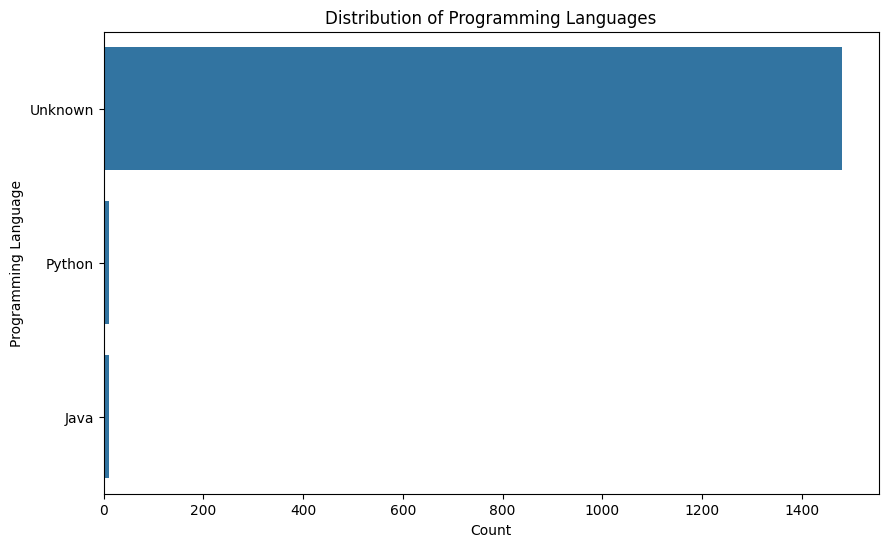

In [3]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='programming_language', order=df['programming_language'].value_counts().index)
plt.title('Distribution of Programming Languages')
plt.xlabel('Count')
plt.ylabel('Programming Language')
plt.show()

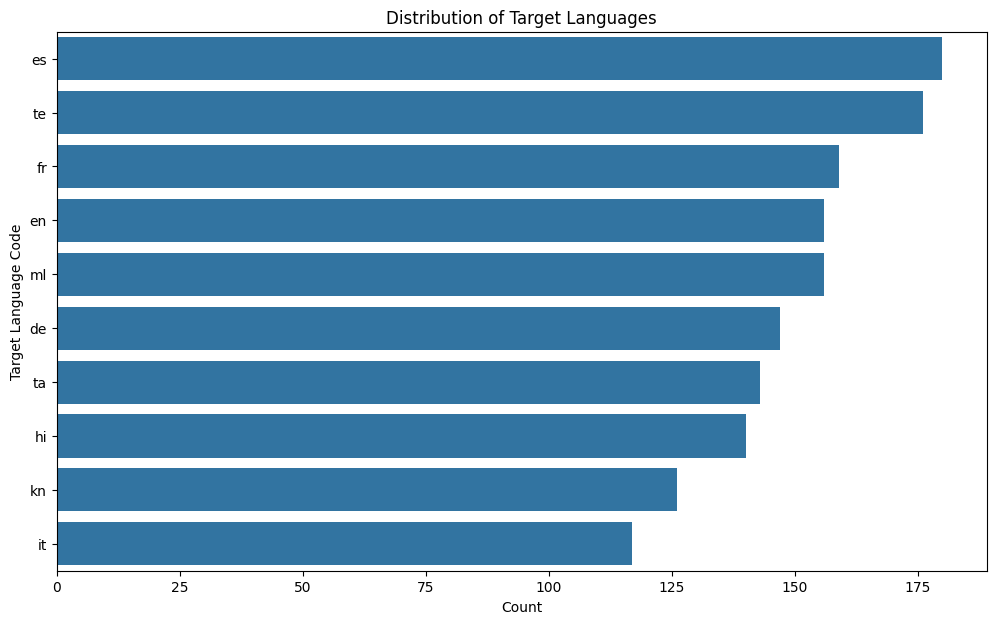

In [4]:
plt.figure(figsize=(12, 7))
sns.countplot(data=df, y='target_language_code', order=df['target_language_code'].value_counts().index)
plt.title('Distribution of Target Languages')
plt.xlabel('Count')
plt.ylabel('Target Language Code')
plt.show()

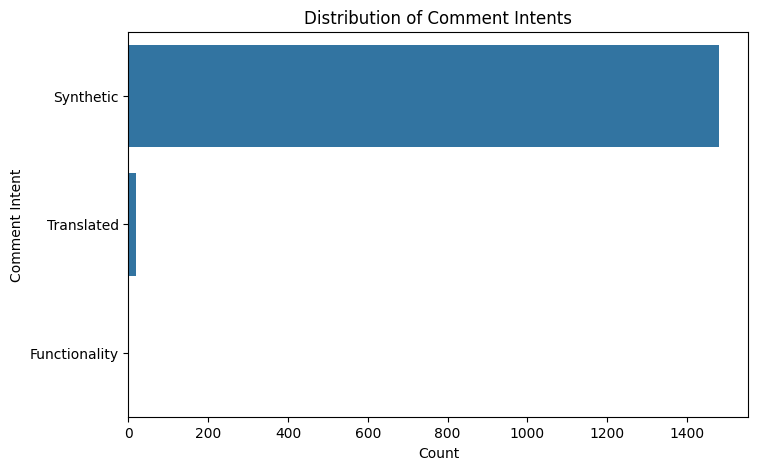

In [5]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, y='comment_intent', order=df['comment_intent'].value_counts().index)
plt.title('Distribution of Comment Intents')
plt.xlabel('Count')
plt.ylabel('Comment Intent')
plt.show()

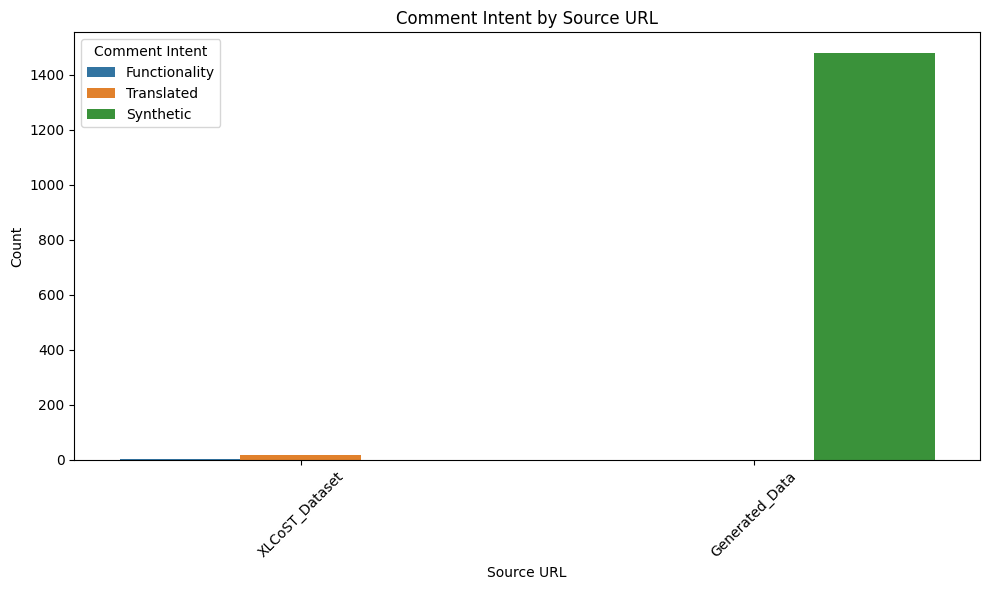

In [6]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='source_url', hue='comment_intent')
plt.title('Comment Intent by Source URL')
plt.xlabel('Source URL')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Comment Intent')
plt.tight_layout()
plt.show()

## 4. Feature Engineering (Embedding Generation).

In [7]:
# Load a pre-trained multilingual model
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# Generate embeddings for processed code snippets and comments
df['code_embeddings'] = df['code_snippet_processed'].fillna('').apply(lambda x: model.encode(x))
df['english_comment_embeddings'] = df['comment_english_processed'].fillna('').apply(lambda x: model.encode(x))
df['target_comment_embeddings'] = df['comment_target_lang_processed'].fillna('').apply(lambda x: model.encode(x))

print("\nEmbeddings generated for code snippets and comments.")
print(f"Shape of a single code embedding: {df['code_embeddings'].iloc[0].shape}")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


Embeddings generated for code snippets and comments.
Shape of a single code embedding: (384,)


## 5. Supervised Learning Validation

In [8]:
# Filter for data from XLCoST_Dataset with English comments and functionality intent
supervised_df = df[(df['source_url'] == 'XLCoST_Dataset') & (df['comment_intent'] == 'Functionality')].copy()

# Ensure there are at least two programming languages in the filtered data for classification
if supervised_df['programming_language'].nunique() < 2:
    print("Warning: Filtered data contains less than two programming languages. Cannot perform classification.")
else:
    X_supervised = np.array(supervised_df['english_comment_embeddings'].tolist())
    y_supervised = supervised_df['programming_language']

    # Use all filtered data for training as the subset is very small
    X_train = X_supervised
    y_train = y_supervised

    print(f"\nSupervised data prepared. X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")


Supervised data prepared. X_train shape: (2, 384), y_train shape: (2,)


In [9]:
# Initialize and train the classifier
classifier = LogisticRegression(max_iter=1000)

if len(y_train.unique()) < 2:
    print("Warning: Training data contains less than two classes. Cannot train classifier.")
else:
    classifier.fit(X_train, y_train)
    print("\nSupervised model (Logistic Regression) trained.")


Supervised model (Logistic Regression) trained.


In [10]:
# Initialize and train the classifier
classifier = LogisticRegression(max_iter=1000)

if len(y_train.unique()) < 2:
    print("Warning: Training data contains less than two classes. Cannot train classifier.")
else:
    classifier.fit(X_train, y_train)
    print("\nSupervised model (Logistic Regression) trained.")


Supervised model (Logistic Regression) trained.


In [11]:
y_pred = classifier.predict(X_train) # Use X_train for prediction as there's no separate test set

# Calculate metrics
# Use y_train for true labels as there's no separate test set
accuracy = accuracy_score(y_train, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_train, y_pred, average='weighted', zero_division=0)

print("\nSupervised Model Evaluation (Proxy Task: Predict Programming Language from English Comment):")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-Score (weighted): {f1:.4f}")


Supervised Model Evaluation (Proxy Task: Predict Programming Language from English Comment):
Accuracy: 1.0000
Precision (weighted): 1.0000
Recall (weighted): 1.0000
F1-Score (weighted): 1.0000


## 6. Unsupervised Learning Validation


Cross-lingual semantic similarity calculated for translated entries.


,comment_english,comment_target_lang,cross_lingual_similarity
2,"Prints Hello, world! to the console.","हैलो, दुनिया प्रिंट!कंसोल के लिए।",0.170221
3,"Prints Hello, world! to the console.","ஹலோ, உலகம்!கன்சோலுக்கு.",0.357483
4,"Prints Hello, world! to the console.","ప్రింట్లు హలో, ప్రపంచం!కన్సోల్‌కు.",0.355901
5,"Prints Hello, world! to the console.","ಹಲೋ, ವಿಶ್ವ!ಕನ್ಸೋಲ್‌ಗೆ.",0.301792
6,"Prints Hello, world! to the console.","ഹലോ, വേൾഡ്!കൺസോളിലേക്ക്.",0.316538



Distribution of Cross-lingual Similarity Scores:
count    18.000000
mean      0.414065
std       0.187832
min       0.087677
25%       0.285068
50%       0.356692
75%       0.521133
max       0.703070
Name: cross_lingual_similarity, dtype: float64


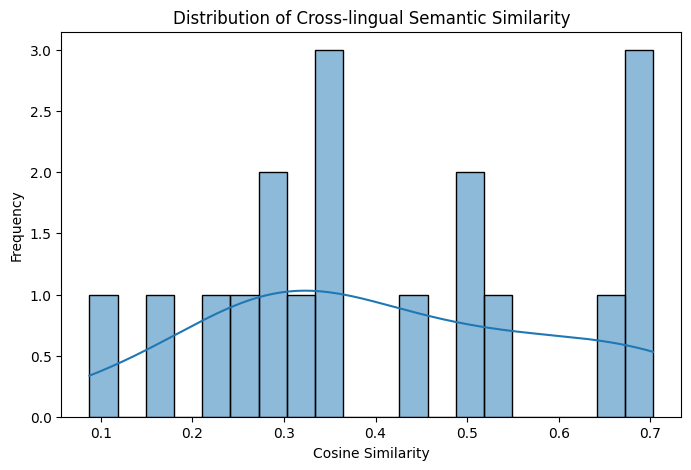

In [12]:
# Filter for translated entries
translated_entries = df[(df['comment_intent'] == 'Translated')].copy()

# Calculate cosine similarity between English and target language comment embeddings
translated_entries['cross_lingual_similarity'] = translated_entries.apply(
    lambda row: 1 - cosine(row['english_comment_embeddings'], row['target_comment_embeddings'])
    if np.any(row['english_comment_embeddings']) and np.any(row['target_comment_embeddings']) else 0.0, axis=1
)

print("\nCross-lingual semantic similarity calculated for translated entries.")
display(translated_entries[['comment_english', 'comment_target_lang', 'cross_lingual_similarity']].head())

# Analyze the distribution of similarity scores
print("\nDistribution of Cross-lingual Similarity Scores:")
print(translated_entries['cross_lingual_similarity'].describe())

# Visualize the distribution
plt.figure(figsize=(8, 5))
sns.histplot(translated_entries['cross_lingual_similarity'], bins=20, kde=True)
plt.title('Distribution of Cross-lingual Semantic Similarity')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.show()

## Anomaly detection using embeddings


In [13]:
# Concatenate the embeddings. Handle potential non-numeric values by converting to list of arrays and stacking.
try:
    X_embeddings = np.vstack(df[['code_embeddings', 'english_comment_embeddings', 'target_comment_embeddings']].apply(lambda x: np.concatenate(x.values), axis=1).values)
except ValueError:
    print("Error concatenating embeddings. Checking embedding shapes.")
    embedding_shapes = df['code_embeddings'].apply(lambda x: x.shape if isinstance(x, np.ndarray) else None).value_counts()
    print(f"Observed embedding shapes:\n{embedding_shapes}")
    X_embeddings = np.hstack((np.vstack(df['code_embeddings'].values),
                              np.vstack(df['english_comment_embeddings'].values),
                              np.vstack(df['target_comment_embeddings'].values)))


print(f"Shape of combined embeddings: {X_embeddings.shape}")

Shape of combined embeddings: (1500, 1152)


In [14]:
# Instantiate Isolation Forest model
isolation_forest = IsolationForest(n_estimators=100, contamination='auto', random_state=42)

# Fit the model and predict anomaly scores
isolation_forest.fit(X_embeddings)
anomaly_scores = isolation_forest.decision_function(X_embeddings)

# Add anomaly scores to the original DataFrame
df['anomaly_score'] = anomaly_scores

print("Anomaly scores calculated and added to the DataFrame.")
display(df[['unique_id', 'anomaly_score']].sort_values(by='anomaly_score').head())

Anomaly scores calculated and added to the DataFrame.


,unique_id,anomaly_score
0,XLCoST_1,-0.245110
8,XLCoST_1_TRANSLATED_de,-0.244550
2,XLCoST_1_TRANSLATED_hi,-0.244192
9,XLCoST_1_TRANSLATED_it,-0.241757
5,XLCoST_1_TRANSLATED_kn,-0.240473


In [15]:
print("\nSummary of Anomaly Detection using Isolation Forest:")
print(f"Identified {len(df[df['anomaly_score'] < 0])} potential anomalies (data points with negative anomaly scores).")
print("\nTop 10 data points with the lowest anomaly scores (most likely anomalies):")
display(df.sort_values(by='anomaly_score').head(10))



Summary of Anomaly Detection using Isolation Forest:
Identified 27 potential anomalies (data points with negative anomaly scores).

Top 10 data points with the lowest anomaly scores (most likely anomalies):


,unique_id,code_snippet,programming_language,comment_english,target_language_code,comment_target_lang,comment_intent,source_url,comment_english_processed,comment_target_lang_processed,code_snippet_processed,code_embeddings,english_comment_embeddings,target_comment_embeddings,anomaly_score
0,XLCoST_1,"def hello_world():\n print('Hello, world!')",Python,"Prints Hello, world! to the console.",en,"Prints Hello, world! to the console.",Functionality,XLCoST_Dataset,prints hello world to the console,prints hello world to the console,def hello_world():\n print(<STR>),"[-0.31836075, 0.017377036, -0.025001232, 0.224...","[-0.16352996, -0.11122151, 0.23978181, 0.02639...","[-0.16352996, -0.11122151, 0.23978181, 0.02639...",-0.245110
8,XLCoST_1_TRANSLATED_de,"def hello_world():\n print('Hello, world!')",Python,"Prints Hello, world! to the console.",de,"Drucke Hallo, Welt!zur Konsole.",Translated,XLCoST_Dataset,prints hello world to the console,drucke hallo weltzur konsole,def hello_world():\n print(<STR>),"[-0.31836075, 0.017377036, -0.025001232, 0.224...","[-0.16352996, -0.11122151, 0.23978181, 0.02639...","[-0.19574244, 0.10095972, -0.0875551, -0.11906...",-0.244550
2,XLCoST_1_TRANSLATED_hi,"def hello_world():\n print('Hello, world!')",Python,"Prints Hello, world! to the console.",hi,"हैलो, दुनिया प्रिंट!कंसोल के लिए।",Translated,XLCoST_Dataset,prints hello world to the console,हल दनय परटकसल क लए,def hello_world():\n print(<STR>),"[-0.31836075, 0.017377036, -0.025001232, 0.224...","[-0.16352996, -0.11122151, 0.23978181, 0.02639...","[0.07260621, 0.09592905, 0.048782703, -0.03994...",-0.244192
9,XLCoST_1_TRANSLATED_it,"def hello_world():\n print('Hello, world!')",Python,"Prints Hello, world! to the console.",it,"Stampa ciao, mondo!alla console.",Translated,XLCoST_Dataset,prints hello world to the console,stampa ciao mondoalla console,def hello_world():\n print(<STR>),"[-0.31836075, 0.017377036, -0.025001232, 0.224...","[-0.16352996, -0.11122151, 0.23978181, 0.02639...","[-0.07345006, -0.007851135, -0.07801807, -0.22...",-0.241757
5,XLCoST_1_TRANSLATED_kn,"def hello_world():\n print('Hello, world!')",Python,"Prints Hello, world! to the console.",kn,"ಹಲೋ, ವಿಶ್ವ!ಕನ್ಸೋಲ್‌ಗೆ.",Translated,XLCoST_Dataset,prints hello world to the console,ಹಲ ವಶವಕನಸಲಗ,def hello_world():\n print(<STR>),"[-0.31836075, 0.017377036, -0.025001232, 0.224...","[-0.16352996, -0.11122151, 0.23978181, 0.02639...","[0.17121384, 0.15634602, -0.02100143, 0.112724...",-0.240473
4,XLCoST_1_TRANSLATED_te,"def hello_world():\n print('Hello, world!')",Python,"Prints Hello, world! to the console.",te,"ప్రింట్లు హలో, ప్రపంచం!కన్సోల్‌కు.",Translated,XLCoST_Dataset,prints hello world to the console,పరటల హల పరపచకనసలక,def hello_world():\n print(<STR>),"[-0.31836075, 0.017377036, -0.025001232, 0.224...","[-0.16352996, -0.11122151, 0.23978181, 0.02639...","[0.18849091, 0.21982457, 0.051027525, 0.096560...",-0.237850
10,XLCoST_1_TRANSLATED_es,"def hello_world():\n print('Hello, world!')",Python,"Prints Hello, world! to the console.",es,"Imprime hola, mundo!a la consola.",Translated,XLCoST_Dataset,prints hello world to the console,imprime hola mundoa la consola,def hello_world():\n print(<STR>),"[-0.31836075, 0.017377036, -0.025001232, 0.224...","[-0.16352996, -0.11122151, 0.23978181, 0.02639...","[0.013561025, 0.14155655, -0.061405465, 0.0238...",-0.234324
7,XLCoST_1_TRANSLATED_fr,"def hello_world():\n print('Hello, world!')",Python,"Prints Hello, world! to the console.",fr,"Imprime bonjour, monde!à la console.",Translated,XLCoST_Dataset,prints hello world to the console,imprime bonjour mondeà la console,def hello_world():\n print(<STR>),"[-0.31836075, 0.017377036, -0.025001232, 0.224...","[-0.16352996, -0.11122151, 0.23978181, 0.02639...","[0.07990951, 0.20870286, 0.017806653, -0.03128...",-0.231379
6,XLCoST_1_TRANSLATED_ml,"def hello_world():\n print('Hello, world!')",Python,"Prints Hello, world! to the console.",ml,"ഹലോ, വേൾഡ്!കൺസോളിലേക്ക്.",Translated,XLCoST_Dataset,prints hello world 

## Clustering of embeddings


In [16]:
# Choose the number of clusters.
n_clusters = 3

# Instantiate KMeans
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

# Fit KMeans to the combined embeddings and get cluster labels
cluster_labels = kmeans.fit_predict(X_embeddings)

# Add cluster labels to the DataFrame
df['cluster_label'] = cluster_labels

print("\nKMeans clustering applied and cluster labels added to the DataFrame.")
display(df[['comment_intent', 'programming_language', 'source_url', 'cluster_label']].head())


KMeans clustering applied and cluster labels added to the DataFrame.


,comment_intent,programming_language,source_url,cluster_label
0,Functionality,Python,XLCoST_Dataset,2
1,Functionality,Java,XLCoST_Dataset,2
2,Translated,Python,XLCoST_Dataset,2
3,Translated,Python,XLCoST_Dataset,2
4,Translated,Python,XLCoST_Dataset,2


In [17]:
print("\nAnalysis of Clusters by Comment Intent:")
display(df.groupby('cluster_label')['comment_intent'].value_counts().unstack(fill_value=0))

print("\nAnalysis of Clusters by Programming Language:")
display(df.groupby('cluster_label')['programming_language'].value_counts().unstack(fill_value=0))

print("\nAnalysis of Clusters by Source URL:")
display(df.groupby('cluster_label')['source_url'].value_counts().unstack(fill_value=0))


Analysis of Clusters by Comment Intent:


comment_intent,Functionality,Synthetic,Translated
cluster_label,,,
0,0,760,0
1,0,720,0
2,2,0,18



Analysis of Clusters by Programming Language:


programming_language,Java,Python,Unknown
cluster_label,,,
0,0,0,760
1,0,0,720
2,10,10,0



Analysis of Clusters by Source URL:


source_url,Generated_Data,XLCoST_Dataset
cluster_label,,
0,760,0
1,720,0
2,0,20


## Visualize embeddings


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


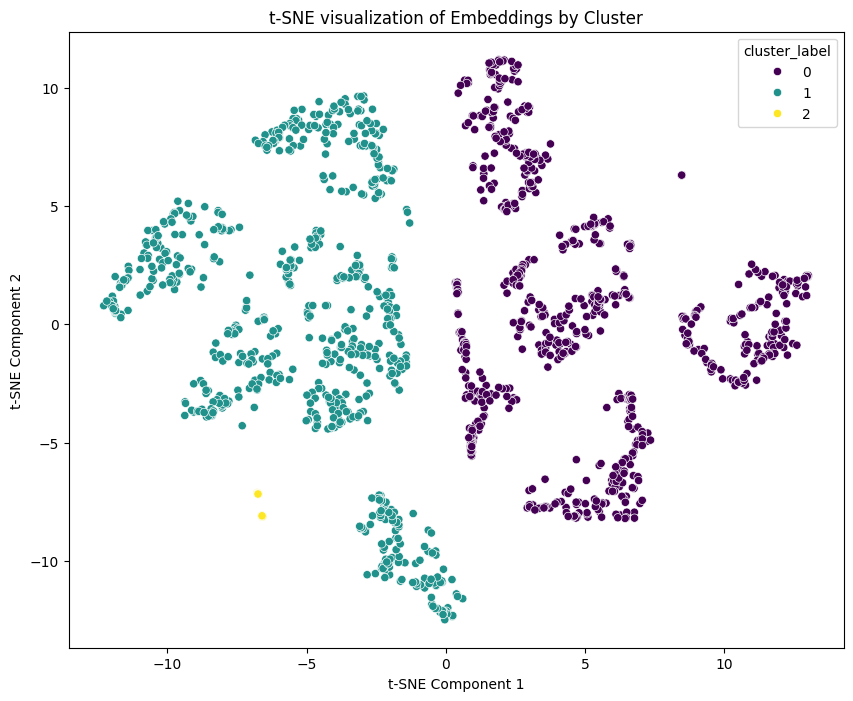

In [18]:
# Instantiate t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=300)

# Apply t-SNE transformation
X_tsne = tsne.fit_transform(X_embeddings)

# Create a scatter plot
plt.figure(figsize=(10, 8))
scatter = sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=df['cluster_label'], palette='viridis', legend='full')
plt.title('t-SNE visualization of Embeddings by Cluster')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()

## Analyze anomalies and clusters

In [19]:
# Filter for rows with low anomaly scores
anomalies = df[df['anomaly_score'] < 0].copy()
print("\nPotential Anomalies (Anomaly Score < 0):")
display(anomalies[['unique_id', 'code_snippet', 'comment_english', 'comment_target_lang', 'comment_intent', 'source_url', 'anomaly_score']])

# Examine a sample of data points for each cluster
print("\nSample Data Points from Each Cluster:")
for cluster_id in sorted(df['cluster_label'].unique()):
    print(f"\nCluster {cluster_id}:")
    # Display a sample of up to 5 rows from each cluster
    display(df[df['cluster_label'] == cluster_id].sample(min(5, len(df[df['cluster_label'] == cluster_id])))[['unique_id', 'code_snippet', 'comment_english', 'comment_target_lang', 'comment_intent', 'source_url', 'cluster_label']])

# Investigate anomalies within clusters
print("\nAnomalies within Clusters:")
# Filter for data points that are anomalies but belong to a cluster
anomalies_in_clusters = anomalies[anomalies['cluster_label'].notna()].copy()
if not anomalies_in_clusters.empty:
    print("Data points identified as anomalies within their assigned clusters:")
    display(anomalies_in_clusters[['unique_id', 'code_snippet', 'comment_english', 'comment_target_lang', 'comment_intent', 'source_url', 'anomaly_score', 'cluster_label']])
else:
    print("No anomalies found within assigned clusters.")



Potential Anomalies (Anomaly Score < 0):


,unique_id,code_snippet,comment_english,comment_target_lang,comment_intent,source_url,anomaly_score
0,XLCoST_1,"def hello_world():\n print('Hello, world!')","Prints Hello, world! to the console.","Prints Hello, world! to the console.",Functionality,XLCoST_Dataset,-0.245110
1,XLCoST_2,public static void main(String[] args) {\n ...,"Main method that prints Hello, world! in Java.","Main method that prints Hello, world! in Java.",Functionality,XLCoST_Dataset,-0.219476
2,XLCoST_1_TRANSLATED_hi,"def hello_world():\n print('Hello, world!')","Prints Hello, world! to the console.","हैलो, दुनिया प्रिंट!कंसोल के लिए।",Translated,XLCoST_Dataset,-0.244192
3,XLCoST_1_TRANSLATED_ta,"def hello_world():\n print('Hello, world!')","Prints Hello, world! to the console.","ஹலோ, உலகம்!கன்சோலுக்கு.",Translated,XLCoST_Dataset,-0.225664
4,XLCoST_1_TRANSLATED_te,"def hello_world():\n print('Hello, world!')","Prints Hello, world! to the console.","ప్రింట్లు హలో, ప్రపంచం!కన్సోల్‌కు.",Translated,XLCoST_Dataset,-0.237850
5,XLCoST_1_TRANSLATED_kn,"def hello_world():\n print('Hello, world!')","Prints Hello, world! to the console.","ಹಲೋ, ವಿಶ್ವ!ಕನ್ಸೋಲ್‌ಗೆ.",Translated,XLCoST_Dataset,-0.240473
6,XLCoST_1_TRANSLATED_ml,"def hello_world():\n print('Hello, world!')","Prints Hello, world! to the console.","ഹലോ, വേൾഡ്!കൺസോളിലേക്ക്.",Translated,XLCoST_Dataset,-0.227692
7,XLCoST_1_TRANSLATED_fr,"def hello_world():\n print('Hello, world!')","Prints Hello, world! to the console.","Imprime bonjour, monde!à la console.",Translated,XLCoST_Dataset,-0.231379
8,XLCoST_1_TRANSLATED_de,"def hello_world():\n print('Hello, world!')","Prints Hello, world! to the console.","Drucke Hallo, Welt!zur Konsole.",Translated,XLCoST_Dataset,-0.244550
9,XLCoST_1_TRANSLATED_it,"def hello_world():\n print('Hello, world!')","Prints Hello, world! to the console.","Stampa ciao, mondo!alla console.",Translated,XLCoST_Dataset,-0.241757



Sample Data Points from Each Cluster:

Cluster 0:


,unique_id,code_snippet,comment_english,comment_target_lang,comment_intent,source_url,cluster_label
1074,DUMMY_1075,// Dummy code snippet 1075\nvoid dummy_functio...,This is a synthetic comment for dummy function...,Dies ist ein synthetischer Kommentar für die D...,Synthetic,Generated_Data,0
1210,DUMMY_1211,// Dummy code snippet 1211\nvoid dummy_functio...,This is a synthetic comment for dummy function...,This is a synthetic comment for dummy function...,Synthetic,Generated_Data,0
704,DUMMY_705,// Dummy code snippet 705\nvoid dummy_function...,This is a synthetic comment for dummy function...,This is a synthetic comment for dummy function...,Synthetic,Generated_Data,0
1010,DUMMY_1011,// Dummy code snippet 1011\nvoid dummy_functio...,This is a synthetic comment for dummy function...,Este es un comentario sintético para la funció...,Synthetic,Generated_Data,0
371,DUMMY_372,// Dummy code snippet 372\nvoid dummy_function...,This is a synthetic comment for dummy function...,Ceci est un commentaire synthétique pour la fo...,Synthetic,Generated_Data,0



Cluster 1:


,unique_id,code_snippet,comment_english,comment_target_lang,comment_intent,source_url,cluster_label
1419,DUMMY_1420,// Dummy code snippet 1420\nvoid dummy_functio...,This is a synthetic comment for dummy function...,1420 ഡമ്മി ഫംഗ്ഷനുള്ള ഒരു സിന്തറ്റിക് അഭിപ്രായ...,Synthetic,Generated_Data,1
1480,DUMMY_1481,// Dummy code snippet 1481\nvoid dummy_functio...,This is a synthetic comment for dummy function...,यह डमी फ़ंक्शन 1481 के लिए एक सिंथेटिक टिप्पणी...,Synthetic,Generated_Data,1
417,DUMMY_418,// Dummy code snippet 418\nvoid dummy_function...,This is a synthetic comment for dummy function...,డమ్మీ ఫంక్షన్ 418 కోసం ఇది సింథటిక్ వ్యాఖ్య.,Synthetic,Generated_Data,1
210,DUMMY_211,// Dummy code snippet 211\nvoid dummy_function...,This is a synthetic comment for dummy function...,यह डमी फ़ंक्शन 211 के लिए एक सिंथेटिक टिप्पणी है।,Synthetic,Generated_Data,1
554,DUMMY_555,// Dummy code snippet 555\nvoid dummy_function...,This is a synthetic comment for dummy function...,यह डमी फ़ंक्शन 555 के लिए एक सिंथेटिक टिप्पणी है।,Synthetic,Generated_Data,1



Cluster 2:


,unique_id,code_snippet,comment_english,comment_target_lang,comment_intent,source_url,cluster_label
14,XLCoST_2_TRANSLATED_kn,public static void main(String[] args) {\n ...,"Main method that prints Hello, world! in Java.","ಹಲೋ, ಜಗತ್ತು ಮುದ್ರಿಸುವ ಮುಖ್ಯ ವಿಧಾನ!ಜಾವಾದಲ್ಲಿ.",Translated,XLCoST_Dataset,2
12,XLCoST_2_TRANSLATED_ta,public static void main(String[] args) {\n ...,"Main method that prints Hello, world! in Java.","ஹலோ, உலகத்தை அச்சிடும் முக்கிய முறை!ஜாவாவில்.",Translated,XLCoST_Dataset,2
15,XLCoST_2_TRANSLATED_ml,public static void main(String[] args) {\n ...,"Main method that prints Hello, world! in Java.","ഹലോ, ലോകം!ജാവയിൽ.",Translated,XLCoST_Dataset,2
2,XLCoST_1_TRANSLATED_hi,"def hello_world():\n print('Hello, world!')","Prints Hello, world! to the console.","हैलो, दुनिया प्रिंट!कंसोल के लिए।",Translated,XLCoST_Dataset,2
3,XLCoST_1_TRANSLATED_ta,"def hello_world():\n print('Hello, world!')","Prints Hello, world! to the console.","ஹலோ, உலகம்!கன்சோலுக்கு.",Translated,XLCoST_Dataset,2



Anomalies within Clusters:
Data points identified as anomalies within their assigned clusters:


,unique_id,code_snippet,comment_english,comment_target_lang,comment_intent,source_url,anomaly_score,cluster_label
0,XLCoST_1,"def hello_world():\n print('Hello, world!')","Prints Hello, world! to the console.","Prints Hello, world! to the console.",Functionality,XLCoST_Dataset,-0.245110,2
1,XLCoST_2,public static void main(String[] args) {\n ...,"Main method that prints Hello, world! in Java.","Main method that prints Hello, world! in Java.",Functionality,XLCoST_Dataset,-0.219476,2
2,XLCoST_1_TRANSLATED_hi,"def hello_world():\n print('Hello, world!')","Prints Hello, world! to the console.","हैलो, दुनिया प्रिंट!कंसोल के लिए।",Translated,XLCoST_Dataset,-0.244192,2
3,XLCoST_1_TRANSLATED_ta,"def hello_world():\n print('Hello, world!')","Prints Hello, world! to the console.","ஹலோ, உலகம்!கன்சோலுக்கு.",Translated,XLCoST_Dataset,-0.225664,2
4,XLCoST_1_TRANSLATED_te,"def hello_world():\n print('Hello, world!')","Prints Hello, world! to the console.","ప్రింట్లు హలో, ప్రపంచం!కన్సోల్‌కు.",Translated,XLCoST_Dataset,-0.237850,2
5,XLCoST_1_TRANSLATED_kn,"def hello_world():\n print('Hello, world!')","Prints Hello, world! to the console.","ಹಲೋ, ವಿಶ್ವ!ಕನ್ಸೋಲ್‌ಗೆ.",Translated,XLCoST_Dataset,-0.240473,2
6,XLCoST_1_TRANSLATED_ml,"def hello_world():\n print('Hello, world!')","Prints Hello, world! to the console.","ഹലോ, വേൾഡ്!കൺസോളിലേക്ക്.",Translated,XLCoST_Dataset,-0.227692,2
7,XLCoST_1_TRANSLATED_fr,"def hello_world():\n print('Hello, world!')","Prints Hello, world! to the console.","Imprime bonjour, monde!à la console.",Translated,XLCoST_Dataset,-0.231379,2
8,XLCoST_1_TRANSLATED_de,"def hello_world():\n print('Hello, world!')","Prints Hello, world! to the console.","Drucke Hallo, Welt!zur Konsole.",Translated,XLCoST_Dataset,-0.244550,2
9,XLCoST_1_TRANSLATED_it,"def hello_world():\n print('Hello, world!')","Prints Hello, world! to the console.","Stampa ciao, mondo!alla console.",Translated,XLCoST_Dataset,-0.241757,2
